<a href="https://colab.research.google.com/github/jashwanthnaiknenavath83-jpg/solar-project-finance-model-germany/blob/main/notebooks/03_scenario_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 50 MW Solar PV in Germany: scenario model with sourced inputs
**Question:** at what CAPEX, site yield and power price does a German solar farm earn its cost of capital?

Run with **Runtime → Run all**. Cells must stay in this order.

| Input | Value | Source |
|---|---|---|
| Specific yield, Central/East | 1,049 kWh/kWp | PVGIS-SARAH3, 52.509 N 13.415 E, fixed 35 deg south, 14% losses |
| Specific yield, South | about 1,215 kWh/kWp | Approximation: PVGIS value x (1,280 / 1,105), ratio from Fraunhofer ISE Table 3 |
| CAPEX | 700 / 800 / 900 EUR/kWp | Fraunhofer ISE (2024), Table 1 (range 700 to 900) |
| OPEX | 13.3 EUR/kW/year | Fraunhofer ISE (2024), Table 2 |
| Lifetime / degradation | 30 years / 0.25% per year | Fraunhofer ISE (2024), Table 2 |
| Debt | 5.0% interest, max 80% gearing | Fraunhofer ISE (2024), Table 2 |
| Equity return benchmark | 6.5% | Fraunhofer ISE (2024), Table 2 |
| Solar capture price | 46.1 EUR/MWh (2025) | SMARD day-ahead DE-LU weighted by SMARD solar generation |
| EEG tender award | 47.9 EUR/MWh | Bundesnetzagentur, ground-mounted solar round of 1 July 2026 (4.79 ct/kWh) |
| Tax, DSCR, tenor | 30%, 1.25x, 18 years | Placeholders |

In [1]:
!pip install numpy-financial -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy_financial as npf
from scipy.optimize import brentq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 6.6 MB/s eta 0:00:00


## 1. Model
The price can be a single number (flat) or a list with one price per year.

In [2]:
def model(price, yield_kwh=1049, capex_mw=800_000, interest=0.05,
          capacity_mw=50, opex_mw=13_300, degradation=0.0025, life=30,
          tax_rate=0.30, dep_years=20, target_dscr=1.25, tenor=18,
          max_gearing=0.80, opex_inflation=0.0, discount_rate=0.035):
    years = np.arange(1, life + 1)
    price_path = np.full(life, float(price)) if np.isscalar(price) else np.asarray(price, float)
    capex = capacity_mw * capex_mw
    gen = capacity_mw * yield_kwh * (1 - degradation) ** (years - 1)
    opex = capacity_mw * opex_mw * (1 + opex_inflation) ** (years - 1)
    ebitda = gen * price_path - opex
    dep = np.where(years <= dep_years, capex / dep_years, 0)
    ebit = ebitda - dep
    cfads = ebitda - np.maximum(ebit, 0) * tax_rate
    ds_cap = np.where(years <= tenor, np.maximum(cfads, 0) / target_dscr, 0)
    debt_sculpted = npf.npv(interest, np.concatenate(([0], ds_cap)))
    debt = max(min(debt_sculpted, max_gearing * capex), 0)
    ds = ds_cap * (debt / debt_sculpted) if debt_sculpted > 0 else ds_cap * 0
    bal, ip = debt, []
    for t in range(life):
        i = bal * interest
        ip.append(i)
        bal -= ds[t] - i
    tax_lev = np.maximum(ebit - np.array(ip), 0) * tax_rate
    eq_cf = ebitda - tax_lev - ds
    eq_irr = npf.irr(np.concatenate(([-(capex - debt)], eq_cf)))
    if np.isnan(eq_irr):
        eq_irr = -1.0
    proj_irr = npf.irr(np.concatenate(([-capex], cfads)))
    if np.isnan(proj_irr):
        proj_irr = -1.0
    disc = (1 + discount_rate) ** years
    lcoe = (capex + (opex / disc).sum()) / (gen / disc).sum()
    return {"equity_irr": eq_irr, "project_irr": proj_irr,
            "gearing": debt / capex, "lcoe": lcoe}

## 2. Validation against Fraunhofer ISE
Run with the study's own inputs (real WACC 3.5%, yields from Table 3, CAPEX 700 and 900 EUR/kWp). The study reports a generation cost of 4.1 to 6.9 ct/kWh for ground-mounted PV.

In [3]:
cases = [("South, CAPEX 700", 1280, 700_000), ("North, CAPEX 900", 935, 900_000)]
for label, y, c in cases:
    r = model(price=50, yield_kwh=y, capex_mw=c, discount_rate=0.035)
    print(f"{label}: LCOE = {r['lcoe'] / 10:.2f} ct/kWh")
print("Fraunhofer ISE (2024) range for ground-mounted PV: 4.1 to 6.9 ct/kWh")

South, CAPEX 700: LCOE = 4.13 ct/kWh
North, CAPEX 900: LCOE = 6.86 ct/kWh
Fraunhofer ISE (2024) range for ground-mounted PV: 4.1 to 6.9 ct/kWh


## 3. Scenarios
Two sites, three CAPEX levels, two revenue routes:
- **Merchant:** sells at the solar capture price for all 30 years
- **EEG award:** 47.9 EUR/MWh for 20 years, then merchant capture price for years 21 to 30

In [4]:
capture = 46.1       # EUR/MWh, SMARD 2025
award = 47.9         # EUR/MWh, Bundesnetzagentur July 2026
sites = {"Central/East (1,049)": 1049, "South (~1,215)": round(1049 * 1280 / 1105)}
capexes = {"700": 700_000, "800": 800_000, "900": 900_000}
eeg_path = np.concatenate((np.full(20, award), np.full(10, capture)))

rows = []
for site, y in sites.items():
    for cname, c in capexes.items():
        for route, p in (("Merchant", capture), ("EEG award", eeg_path)):
            r = model(price=p, yield_kwh=y, capex_mw=c)
            rows.append({"Site": site, "CAPEX (EUR/kWp)": cname, "Revenue": route,
                         "Project IRR": f"{r['project_irr']:.1%}",
                         "Equity IRR": f"{r['equity_irr']:.1%}",
                         "Gearing": f"{r['gearing']:.0%}"})
scen = pd.DataFrame(rows)
scen

,Site,CAPEX (EUR/kWp),Revenue,Project IRR,Equity IRR,Gearing
0,"Central/East (1,049)",700,Merchant,1.9%,0.4%,46%
1,"Central/East (1,049)",700,EEG award,2.2%,0.8%,48%
2,"Central/East (1,049)",800,Merchant,0.9%,-0.7%,40%
3,"Central/East (1,049)",800,EEG award,1.2%,-0.4%,42%
4,"Central/East (1,049)",900,Merchant,0.0%,-1.7%,36%
5,"Central/East (1,049)",900,EEG award,0.3%,-1.4%,37%
6,"South (~1,215)",700,Merchant,3.2%,2.6%,53%
7,"South (~1,215)",700,EEG award,3.5%,3.1%,55%
8,"South (~1,215)",800,Merchant,2.4%,1.1%,48%
9,"South (~1,215)",800,EEG award,2.6%,1.5%,50%


## 4. What flat price is needed for a 6.5% equity return?
6.5% is the return on equity assumed by Fraunhofer ISE (Table 2). Compare with the solar capture price (46.1) and the EEG award (47.9).

In [5]:
target = 0.065
rows = []
for site, y in sites.items():
    for cname, c in capexes.items():
        p = brentq(lambda x: model(price=x, yield_kwh=y, capex_mw=c)["equity_irr"] - target, 30, 150)
        rows.append({"Site": site, "CAPEX (EUR/kWp)": cname, "Required flat price (EUR/MWh)": round(p, 1)})
req = pd.DataFrame(rows)
print(f"Reference: capture price {capture} EUR/MWh, EEG award {award} EUR/MWh")
req

Reference: capture price 46.1 EUR/MWh, EEG award 47.9 EUR/MWh


,Site,CAPEX (EUR/kWp),Required flat price (EUR/MWh)
0,"Central/East (1,049)",700,65.3
1,"Central/East (1,049)",800,72.8
2,"Central/East (1,049)",900,80.3
3,"South (~1,215)",700,56.4
4,"South (~1,215)",800,62.8
5,"South (~1,215)",900,69.3


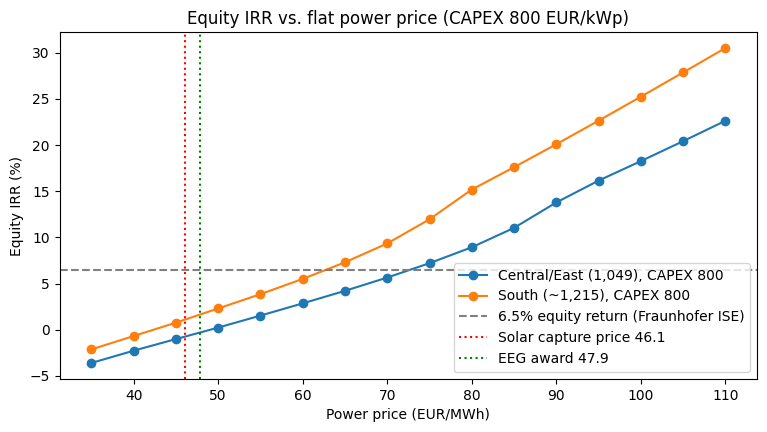

In [6]:
prices = np.arange(35, 111, 5)
plt.figure(figsize=(9, 4.5))
for site, y in sites.items():
    irr = [model(price=p, yield_kwh=y, capex_mw=800_000)["equity_irr"] * 100 for p in prices]
    plt.plot(prices, irr, marker="o", label=f"{site}, CAPEX 800")
plt.axhline(6.5, color="grey", linestyle="--", label="6.5% equity return (Fraunhofer ISE)")
plt.axvline(capture, color="red", linestyle=":", label="Solar capture price 46.1")
plt.axvline(award, color="green", linestyle=":", label="EEG award 47.9")
plt.title("Equity IRR vs. flat power price (CAPEX 800 EUR/kWp)")
plt.xlabel("Power price (EUR/MWh)")
plt.ylabel("Equity IRR (%)")
plt.legend()
plt.show()

## 5. Effect of cost inflation
The EEG award is fixed in nominal terms, while OPEX rises. Fraunhofer ISE assumes 1.8% inflation.

In [7]:
y = sites["South (~1,215)"]
for infl in (0.0, 0.018):
    r = model(price=eeg_path, yield_kwh=y, capex_mw=700_000, opex_inflation=infl)
    print(f"South, CAPEX 700, EEG award, OPEX inflation {infl:.1%}: equity IRR {r['equity_irr']:.1%}")

South, CAPEX 700, EEG award, OPEX inflation 0.0%: equity IRR 3.1%
South, CAPEX 700, EEG award, OPEX inflation 1.8%: equity IRR 2.1%


In [8]:
rows = []
for site, y in sites.items():
    for dscr in (1.25, 1.20, 1.15):
        for tenor in (18, 20):
            r = model(price=eeg_path, yield_kwh=y, capex_mw=700_000,
                      target_dscr=dscr, tenor=tenor)
            p = brentq(lambda x: model(price=x, yield_kwh=y, capex_mw=700_000,
                                       target_dscr=dscr, tenor=tenor)["equity_irr"] - 0.065, 30, 150)
            rows.append({"Site": site, "DSCR": dscr, "Tenor": tenor,
                         "Equity IRR (EEG)": f"{r['equity_irr']:.1%}",
                         "Gearing": f"{r['gearing']:.0%}",
                         "Price for 6.5% equity": round(p, 1)})
pd.DataFrame(rows)

,Site,DSCR,Tenor,Equity IRR (EEG),Gearing,Price for 6.5% equity
0,"Central/East (1,049)",1.25,18,0.8%,48%,65.3
1,"Central/East (1,049)",1.25,20,0.4%,51%,64.3
2,"Central/East (1,049)",1.20,18,0.7%,50%,65.1
3,"Central/East (1,049)",1.20,20,0.3%,53%,64.1
4,"Central/East (1,049)",1.15,18,0.6%,52%,64.8
5,"Central/East (1,049)",1.15,20,0.1%,55%,63.8
6,"South (~1,215)",1.25,18,3.1%,55%,56.4
7,"South (~1,215)",1.25,20,3.0%,59%,55.5
8,"South (~1,215)",1.20,18,3.1%,57%,56.2
9,"South (~1,215)",1.20,20,2.9%,61%,55.3


## 6. Key findings and limitations
**Findings:**
- Model reproduces Fraunhofer ISE's generation cost range (4.13 and 6.86 ct/kWh vs. 4.1 to 6.9)
- At the solar capture price (46.1 EUR/MWh) and the EEG award (47.9 EUR/MWh), no scenario reaches a 6.5% equity return; equity IRR ranges from -1.7% to 3.1%
- Flat price needed for 6.5% equity: 56.4 EUR/MWh (South, CAPEX 700) up to 80.3 (Central/East, CAPEX 900)
- Site yield is worth about 9 EUR/MWh and each +100 EUR/kWp CAPEX about 7.5 EUR/MWh
- OPEX inflation of 1.8% lowers the best case (South, CAPEX 700, EEG) from 3.1% to 2.1% equity IRR
- Result is robust to financing terms: lowering DSCR from 1.25x to 1.15x and extending tenor from 18 to 20 years moves the required price by at most 1.5 EUR/MWh, because project IRR (about 3.5%) is below the 5% cost of debt

**Limitations:**
- Flat nominal prices; no price curve, only OPEX inflation tested in section 5
- Simplified tax (30% flat, 20-year straight-line depreciation, no loss carry-forward)
- No reserve accounts, construction period or negative-price curtailment rules
- DSCR and tenor are placeholders, but results are insensitive to them (see above)
- South yield is a scaled approximation, not a PVGIS run
- Solar capture price is a national 2025 value (day-ahead only)